In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import sympy as sp

In [5]:
# upr 1
# a)

x, y = sp.Symbol('x'), sp.Symbol('y')
z = sp.cos(3 * x + y**2)

dzdx = sp.diff(z, x, 1)
dzdy = sp.diff(z, y, 1)
d2zdxdy = sp.diff(dzdx, y, 1)
d2zdydx = sp.diff(dzdy, x, 1)
d2zdx2 = sp.diff(z, x, 2)
d2zdy2 = sp.diff(z, y, 2)
print('dzdx =', dzdx)
print('dzdy =', dzdy)
print('d2zdxdy =', d2zdxdy)
print('d2zdydx =', d2zdydx)
print('d2zdx2 =', d2zdx2)
print('d2zdy2 =', d2zdy2)

dzdx = -3*sin(3*x + y**2)
dzdy = -2*y*sin(3*x + y**2)
d2zdxdy = -6*y*cos(3*x + y**2)
d2zdydx = -6*y*cos(3*x + y**2)
d2zdx2 = -9*cos(3*x + y**2)
d2zdy2 = -2*(2*y**2*cos(3*x + y**2) + sin(3*x + y**2))


In [11]:
# upr 1
# b)

x = sp.Symbol('x')
y = sp.Symbol('y')
z = sp.Symbol('z')
f = 2 * x**3 * y + x - z

grad_x = sp.diff(f, x).subs([(x, 1), (y, 2), (z, -3)]) 
grad_y = sp.diff(f, y).subs([(x, 1), (y, 2), (z, -3)])
grad_z = sp.diff(f, z).subs([(x, 1), (y, 2), (z, -3)])
        
print('grad{f}|(1, 2, -3) = (', grad_x, grad_y, grad_z, ')')

grad{f}|(1, 2, -3) = ( 13 2 -1 )


In [26]:
# upr 2

r, t = sp.symbols('r t')
x = r * sp.cos(t)
y = r * sp.sin(t)
z = z
A = sp.Matrix([[x, y, z]])
B = sp.Matrix([[sp.diff(A, r)], [sp.diff(A, t)], [sp.diff(A, z)]])
B

Matrix([
[   cos(t),   sin(t), 0],
[-r*sin(t), r*cos(t), 0],
[        0,        0, 1]])

In [28]:
sp.pprint(sp.simplify(B.det()))

r


In [50]:
# upr 3
# a)

x = sp.Symbol('x')
y = sp.Symbol('y')
dx = 0.1
dy = -0.2
z = x * y**2 + 2 * y - x**2
dz = sp.diff(z, x).subs([(x, 2), (y, -1)]) * dx
dz += sp.diff(z, y).subs([(x, 2), (y, -1)]) * dy
print(dz)

0.100000000000000


In [49]:
# upr 3
# b)

dx = sp.Symbol('dx')
dy = sp.Symbol('dy')
x = sp.Symbol('x')
y = sp.Symbol('y')

def df(f, x, y, dx, dy, x0, y0, dx0, dy0):
    df = sp.diff(f, x) * dx + sp.diff(f, y) * dy
    df_0 = df.subs([(x, x0), (y, y0), (dx, dx0), (dy, dy0)])
    return df, df_0

dx0 = 0.1
dy0 = -0.2
z = x * y**2 + 2 * y - x**2
df(z, x, y, dx, dy, 2, -1, dx0, dy0)

(dx*(-2*x + y**2) + dy*(2*x*y + 2), 0.100000000000000)

In [52]:
# upr 4
# a)

x = sp.Symbol('x')
y = sp.Symbol('y')
dx = 0.1
dy = -0.2
z = x * y**2 + 2 * y - x**2
d2z = sp.diff(z, x, 2).subs([(x, 2), (y, -1)]) * dx**2
d2z += sp.diff(z, y, 2).subs([(x, 2), (y, -1)]) * dy**2
d2z += 2 * sp.diff(sp.diff(z, x), y).subs([(x, 2), (y, -1)]) * dx * dy
print(d2z)

0.220000000000000


In [58]:
# upr 4
# b)

dx = sp.Symbol('dx')
dy = sp.Symbol('dy')
x = sp.Symbol('x')
y = sp.Symbol('y')

def d2f(f, x, y, dx, dy, x0, y0, dx0, dy0):
    d2f = sp.diff(f, x, 2) * dx**2 + sp.diff(f, y, 2) * dy**2
    d2f += 2 * sp.diff(sp.diff(f, x), y) * dx * dy
    d2f_0 = d2f.subs([(x, x0), (y, y0), (dx, dx0), (dy, dy0)])
    return d2f, d2f_0

dx0 = 0.1
dy0 = -0.2
z = x * y**2 + 2 * y - x**2
d2f(z, x, y, dx, dy, 2, -1, dx0, dy0)

(-2*dx**2 + 4*dx*dy*y + 2*dy**2*x, 0.220000000000000)

In [63]:
# upr 5
# a)

dx = sp.Symbol('dx')
dy = sp.Symbol('dy')
x = sp.Symbol('x')
y = sp.Symbol('y')

def taylor1(f, x, y, dx, dy, x0, y0, dx0, dy0):
    p1_symb = f.subs([(x, x0), (y, y0)]) + df(f, x, y, dx, dy, x0, y0, dx0, dy0)[0]
    p1 = f.subs([(x, x0), (y, y0)])
    p1 += df(f, x, y, dx, dy, x0, y0, dx0, dy0)[1]
    return p1_symb, p1

In [64]:
# upr 5
# b)

dx = sp.Symbol('dx')
dy = sp.Symbol('dy')
x = sp.Symbol('x')
y = sp.Symbol('y')
f = (2 * x**2 + y**2)**2

taylor1(f, x, y, dx, dy, 1, 2, -0.2, 0.2)

(8*dx*x*(2*x**2 + y**2) + 4*dy*y*(2*x**2 + y**2) + 36, 36)

<Figure size 640x480 with 0 Axes>

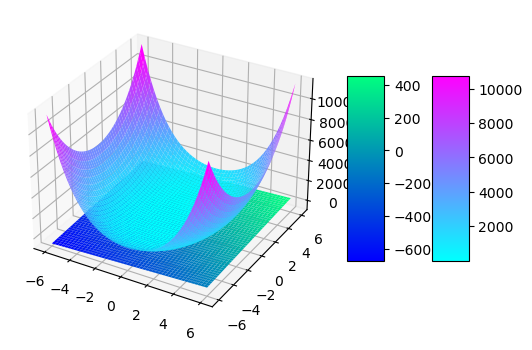

In [75]:
# upr 5
# c)

from matplotlib import cm

x0 = 1
y0 = 2

fig = plt.figure()
xs = np.linspace(-6, 6, 50)
ys = np.linspace(-6, 6, 50)

X, Y = np.meshgrid(xs, ys)
Z = (2 * X**2 + Y**2)**2
p1 = taylor1(f, x, y, dx, dy, 1, 2, -0.2, 0.2)[0]
ZZ = f.subs([(x, 1), (y, 2)]) + (X - 1) * 8 * x0 * (2 * x0**2 + y0**2)
ZZ += (Y - 2) * 4 * y0 * (2 * x0**2 + y0**2)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X, Y, Z, cmap=cm.cool, linewidth=0)
surf1 = ax.plot_surface(X, Y, ZZ, cmap=cm.winter, linewidth=0)
fig.colorbar(surf, shrink=0.5, aspect=5)
fig.colorbar(surf1, shrink=0.5, aspect=5)
plt.show()

In [80]:
# upr 6
# a)

dx = sp.Symbol('dx')
dy = sp.Symbol('dy')
x = sp.Symbol('x')
y = sp.Symbol('y')

def taylor2(f, x, y, dx, dy, x0, y0, dx0, dy0):
    p2_symb = f.subs([(x, x0), (y, y0)]) + df(f, x, y, dx, dy, x0, y0, dx0, dy0)[0]
    p2_symb += d2f(f, x, y, dx, dy, x0, y0, dx0, dy0)[0] / 2
    p2 = f.subs([(x, x0), (y, y0)])
    p2 += df(f, x, y, dx, dy, x0, y0, dx0, dy0)[1]
    p2 += d2f(f, x, y, dx, dy, x0, y0, dx0, dy0)[1] / 2
    return p2_symb, p2

In [84]:
# upr 6
# b)

dx = sp.Symbol('dx')
dy = sp.Symbol('dy')
x = sp.Symbol('x')
y = sp.Symbol('y')
f = (2 * x**2 + y**2)**2

print(taylor2(f, x, y, dx, dy, 1, 2, -0.2, 0.2)[1])

37.4400000000000


In [85]:
print(taylor1(f, x, y, dx, dy, 1, 2, -0.2, 0.2)[1])

36


In [86]:
(2 * 0.8**2 + 2.2**2)**2

37.454400000000014

In [89]:
taylor2(f, x, y, dx, dy, 1, 2, -0.2, 0.2)[0]

4*dx**2*(6*x**2 + y**2) + 16*dx*dy*x*y + 8*dx*x*(2*x**2 + y**2) + 2*dy**2*(2*x**2 + 3*y**2) + 4*dy*y*(2*x**2 + y**2) + 36

<Figure size 640x480 with 0 Axes>

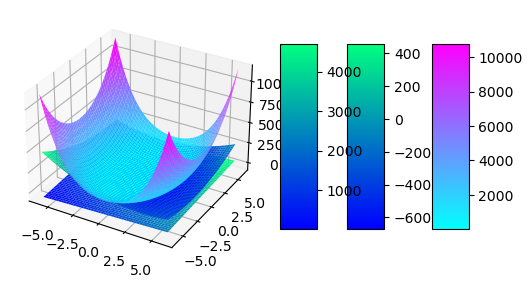

In [92]:
# upr 6
# c)

from matplotlib import cm

x0 = 1
y0 = 2

fig = plt.figure()
xs = np.linspace(-6, 6, 50)
ys = np.linspace(-6, 6, 50)

X, Y = np.meshgrid(xs, ys)
Z = (2 * X**2 + Y**2)**2

p1 = taylor1(f, x, y, dx, dy, 1, 2, -0.2, 0.2)[0]
ZZ = f.subs([(x, 1), (y, 2)]) + (X - 1) * 8 * x0 * (2 * x0**2 + y0**2)
ZZ += (Y - 2) * 4 * y0 * (2 * x0**2 + y0**2)

ZZZ = ZZ + 1 / 2 * sp.diff(f, x, 2).subs([(x, x0), (y, y0)]) * (X - x0)**2
ZZZ += 1 / 2 * sp.diff(f, y, 2).subs([(x, x0), (y, y0)]) * (Y - y0)**2
ZZZ += sp.diff(sp.diff(f, x), y).subs([(x, x0), (y, y0)]) * (X - x0) * (Y - y0)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X, Y, Z, cmap=cm.cool, linewidth=0)
surf1 = ax.plot_surface(X, Y, ZZ, cmap=cm.winter, linewidth=0)
surf2 = ax.plot_surface(X, Y, ZZZ, cmap=cm.winter, linewidth=0)
fig.colorbar(surf, shrink=0.5, aspect=5)
fig.colorbar(surf1, shrink=0.5, aspect=5)
fig.colorbar(surf2, shrink=0.5, aspect=5)
plt.show()

In [98]:
# 1C

r, theta, phi = sp.symbols('r theta phi')
x = r * sp.cos(phi) * sp.cos(theta)
y = r * sp.sin(phi) * sp.cos(theta)
z = r * sp.sin(theta)
A = sp.Matrix([[x, y, z]])
B = sp.Matrix([[sp.diff(A, r)], [sp.diff(A, phi)], [sp.diff(A, theta)]])
B

Matrix([
[   cos(phi)*cos(theta),    sin(phi)*cos(theta),   sin(theta)],
[-r*sin(phi)*cos(theta),  r*cos(phi)*cos(theta),            0],
[-r*sin(theta)*cos(phi), -r*sin(phi)*sin(theta), r*cos(theta)]])

In [99]:
sp.pprint(sp.simplify(B.det()))

 2       
r ⋅cos(θ)


In [107]:
# 2C

def teilor2_n(f, X, Dx, x0, delx):
    sizex = len(X)
    dif1 = 0
    dif2 = 0
    f0 = f
    for i in range(0, sizex):
        dif1 = dif1 + sp.diff(f,X[i]) * Dx[i]
    for i in range(0, sizex):
        f0 = f0.subs(X[i], x0[i])
    for i in range(0, sizex):
        for j in range(0, sizex):
            df2 = sp.diff(sp.diff(f, X[i]), X[j]) * Dx[i] * Dx[j]
            if (i!=j):
                df2 = df2 * 2
            dif2 = dif2 + df2
    df1subs = dif1
    df2subs = dif2
    for i in range(0, sizex):
        df1subs = df1subs.subs(X[i], x0[i])
        df2subs = df2subs.subs(X[i], x0[i])
    for i in range(0, sizex):
        df1subs = df1subs.subs(Dx[i], delx[i])
        df2subs = df2subs.subs(Dx[i], delx[i])
    
    p1= f0 + df1subs + 0.5 * df2subs
    p1sim = f + dif1 + 0.5 * dif2
    print(p1sim)
    print(p1)
    return p1sim


x, y, z, w, dx, dy, dz, dw = sp.symbols('x y z w dx dy dz dw')
f = x**2 - w * (sp.sqrt(y) - z) + z * x
X = [x, y, z, w]
x0 = [2, -1, 4, -3]
Dx = [dx, dy, dz, dw]
delx = [0.1, -0.2, 0.5, -0.2]
teilor2_n(f, X, Dx, x0, delx)

-1.0*dw*dy/sqrt(y) + 2.0*dw*dz + dw*(-sqrt(y) + z) + 1.0*dx**2 + 2.0*dx*dz + dx*(2*x + z) + 0.125*dy**2*w/y**(3/2) - dy*w/(2*sqrt(y)) + dz*(w + x) - w*(sqrt(y) - z) + x**2 + x*z
-0.59 + 3.525*I


-1.0*dw*dy/sqrt(y) + 2.0*dw*dz + dw*(-sqrt(y) + z) + 1.0*dx**2 + 2.0*dx*dz + dx*(2*x + z) + 0.125*dy**2*w/y**(3/2) - dy*w/(2*sqrt(y)) + dz*(w + x) - w*(sqrt(y) - z) + x**2 + x*z